# Ejercicio No1: Detección de Bordes con OpenCV

In [100]:
# Importar librerías necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [101]:
# Configurar ruta de la carpeta Data
data_folder = Path('Data')

# Verificar que la carpeta existe
if not data_folder.exists():
    print(f"❌ Error: La carpeta '{data_folder}' no existe")
    print(f"   Ruta buscada: {data_folder.absolute()}")
    img_original = None
else:
    # Buscar todas las imágenes en la carpeta Data
    # Extensiones de imagen soportadas
    extensiones = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tif', '*.tiff', "*.avif"]
    
    imagenes = []
    for ext in extensiones:
        imagenes.extend(list(data_folder.glob(ext)))
    
    if len(imagenes) == 0:
        print(f"❌ Error: No se encontraron imágenes en la carpeta '{data_folder}'")
        img_original = None
    else:
        # Seleccionar una imagen aleatoria
        imagen_seleccionada = random.choice(imagenes)
        
        print(f"📂 Carpeta Data encontrada: {data_folder.absolute()}")
        print(f"📸 Imágenes disponibles: {len(imagenes)}")
        print(f"🎲 Imagen seleccionada aleatoriamente: {imagen_seleccionada.name}\n")
        
        # Cargar la imagen seleccionada
        img_original = cv2.imread(str(imagen_seleccionada))
        
        # Verificar que la imagen se cargó correctamente
        if img_original is None:
            print(f"❌ Error: No se pudo cargar la imagen {imagen_seleccionada.name}")
        else:
            print(f"✅ Imagen cargada exitosamente")
            print(f"   Archivo: {imagen_seleccionada.name}")
            print(f"   Dimensiones: {img_original.shape}")
            print(f"   Tipo de datos: {img_original.dtype}")

📂 Carpeta Data encontrada: c:\Users\cabarca2\MAESTRIA_IA\Visión-por-computador\semana1\Data
📸 Imágenes disponibles: 6
🎲 Imagen seleccionada aleatoriamente: Copo2.jpeg

✅ Imagen cargada exitosamente
   Archivo: Copo2.jpeg
   Dimensiones: (1214, 871, 3)
   Tipo de datos: uint8


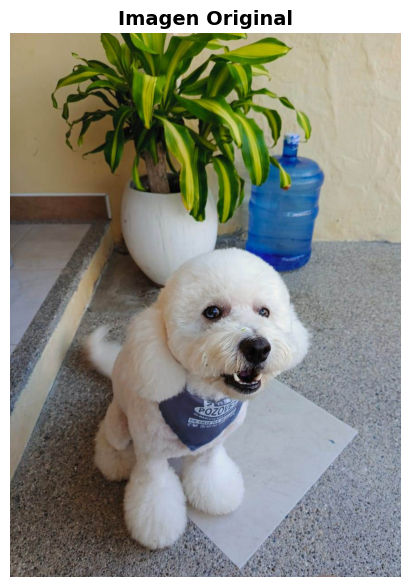

In [102]:
# 1. MOSTRAR IMAGEN ORIGINAL
# Convertir de BGR a RGB para visualización correcta (OpenCV usa BGR, Matplotlib usa RGB)
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title('Imagen Original', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [103]:
# 2. CONVERTIR A ESCALA DE GRISES
# La detección de bordes funciona mejor en imágenes en escala de grises
img_gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

print(f"✅ Imagen convertida a escala de grises: {img_gray.shape}")

✅ Imagen convertida a escala de grises: (1214, 871)


In [104]:
# 3. APLICAR FILTRO CANNY
# Algoritmo Canny: reduce ruido, calcula gradientes, suprime no-máximos, umbralización por histéresis
threshold1 = 50   # Umbral bajo
threshold2 = 150  # Umbral alto (debe ser 2-3x el umbral bajo)

edges_canny = cv2.Canny(img_gray, threshold1, threshold2)

print(f"✅ Filtro Canny aplicado: {np.sum(edges_canny > 0):,} píxeles de borde detectados")

✅ Filtro Canny aplicado: 112,427 píxeles de borde detectados


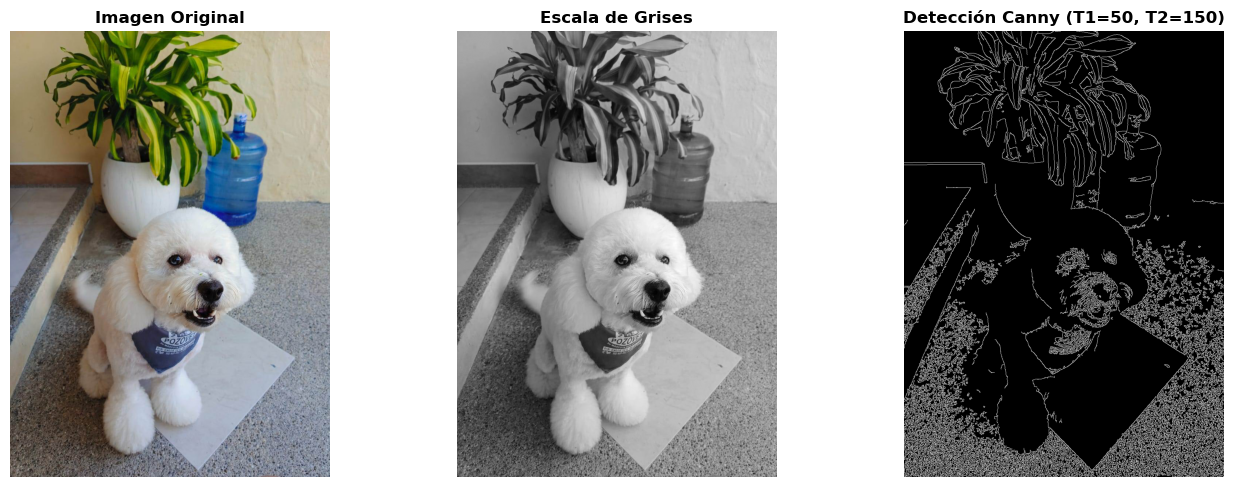

In [105]:
# 4. MOSTRAR IMAGEN PROCESADA CON CANNY
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Escala de Grises', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges_canny, cmap='gray')
plt.title(f'Detección Canny (T1={threshold1}, T2={threshold2})', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

In [106]:
# 5. OTRO FILTRO: SOBEL
# Sobel detecta bordes calculando gradientes en direcciones X e Y
# Es más rápido que Canny pero menos preciso (bordes más gruesos)

# Sobel en dirección X (detecta bordes verticales)
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
# Sobel en dirección Y (detecta bordes horizontales)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
# Magnitud del gradiente (combina X e Y usando teorema de Pitágoras)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_magnitude = np.uint8(sobel_magnitude)

# Binarizar para comparar mejor con Canny
_, sobel_binary = cv2.threshold(sobel_magnitude, 50, 255, cv2.THRESH_BINARY)

print(f"✅ Filtro Sobel aplicado: dimensiones {sobel_magnitude.shape}")

✅ Filtro Sobel aplicado: dimensiones (1214, 871)


In [107]:
# 6. APLICAR SOBEL A IMAGEN ORIGINAL Y A IMAGEN PROCESADA CON CANNY

# A) Sobel sobre imagen original (en grises) - Ya calculado arriba
sobel_from_original = sobel_binary

# B) Sobel sobre imagen YA procesada con Canny (detecta "bordes de bordes")
sobel_x_canny = cv2.Sobel(edges_canny, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_canny = cv2.Sobel(edges_canny, cv2.CV_64F, 0, 1, ksize=3)
sobel_from_canny = np.sqrt(sobel_x_canny**2 + sobel_y_canny**2)
sobel_from_canny = np.uint8(sobel_from_canny)

print("✅ Sobel aplicado a:")
print("   1. Imagen original (grises)")
print("   2. Imagen procesada con Canny")

✅ Sobel aplicado a:
   1. Imagen original (grises)
   2. Imagen procesada con Canny


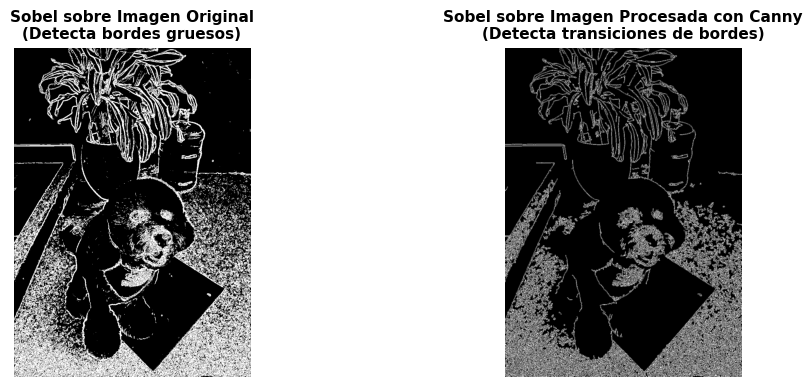

In [108]:
# 7. MOSTRAR RESULTADOS DE LAS 2 IMÁGENES PROCESADAS CON SOBEL
plt.figure(figsize=(12, 4))

# Imagen 1: Sobel sobre original
plt.subplot(1, 2, 1)
plt.imshow(sobel_from_original, cmap='gray')
plt.title('Sobel sobre Imagen Original\n(Detecta bordes gruesos)', fontsize=11, fontweight='bold')
plt.axis('off')

# Imagen 2: Sobel sobre Canny
plt.subplot(1, 2, 2)
plt.imshow(sobel_from_canny, cmap='gray')
plt.title('Sobel sobre Imagen Procesada con Canny\n(Detecta transiciones de bordes)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

In [109]:
# 8. DIFERENCIAS ENTRE LOS RESULTADOS DE LAS DOS IMÁGENES

print("\n" + "="*70)
print("                    ANÁLISIS DE DIFERENCIAS")
print("="*70)

print("\n1️⃣ SOBEL SOBRE IMAGEN ORIGINAL:")
print("   • Detecta bordes en la imagen en escala de grises")
print("   • Bordes GRUESOS (2-3 píxeles de ancho)")
print("   • Más sensible al ruido y texturas")
print("   • Útil para análisis rápido de gradientes")
print(f"   • Píxeles detectados: {np.sum(sobel_from_original > 0):,}")

print("\n2️⃣ SOBEL SOBRE IMAGEN PROCESADA CON CANNY:")
print("   • Detecta cambios en imagen que YA tiene bordes")
print("   • Produce 'bordes de bordes' (transiciones blanco→negro)")
print("   • Resultado REDUNDANTE: no agrega información útil")
print("   • Similar a operación morfológica de gradiente")
print(f"   • Píxeles detectados: {np.sum(sobel_from_canny > 0):,}")

print("\n📊 COMPARACIÓN CON CANNY:")
canny_pixels = np.sum(edges_canny > 0)
sobel_pixels = np.sum(sobel_from_original > 0)
print(f"   • Canny: {canny_pixels:,} píxeles (bordes finos, precisos)")
print(f"   • Sobel: {sobel_pixels:,} píxeles (bordes gruesos)")
print(f"   • Ratio: Sobel detecta {sobel_pixels/canny_pixels:.2f}x más píxeles que Canny")

print("\n🎯 CONCLUSIÓN:")
print("   • Canny: Mejor para segmentación precisa (bordes de 1 píxel)")
print("   • Sobel: Más rápido, útil para información direccional")
print("   • Sobel sobre Canny: NO tiene utilidad práctica (redundante)")

print("\n" + "="*70)


                    ANÁLISIS DE DIFERENCIAS

1️⃣ SOBEL SOBRE IMAGEN ORIGINAL:
   • Detecta bordes en la imagen en escala de grises
   • Bordes GRUESOS (2-3 píxeles de ancho)
   • Más sensible al ruido y texturas
   • Útil para análisis rápido de gradientes
   • Píxeles detectados: 273,468

2️⃣ SOBEL SOBRE IMAGEN PROCESADA CON CANNY:
   • Detecta cambios en imagen que YA tiene bordes
   • Produce 'bordes de bordes' (transiciones blanco→negro)
   • Resultado REDUNDANTE: no agrega información útil
   • Similar a operación morfológica de gradiente
   • Píxeles detectados: 289,778

📊 COMPARACIÓN CON CANNY:
   • Canny: 112,427 píxeles (bordes finos, precisos)
   • Sobel: 273,468 píxeles (bordes gruesos)
   • Ratio: Sobel detecta 2.43x más píxeles que Canny

🎯 CONCLUSIÓN:
   • Canny: Mejor para segmentación precisa (bordes de 1 píxel)
   • Sobel: Más rápido, útil para información direccional
   • Sobel sobre Canny: NO tiene utilidad práctica (redundante)

